In [1]:
!pip install google


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist

In [3]:
(X_train , Y_train ) , (X_test, Y_test) = mnist.load_data()

In [4]:
type(X_train)

numpy.ndarray

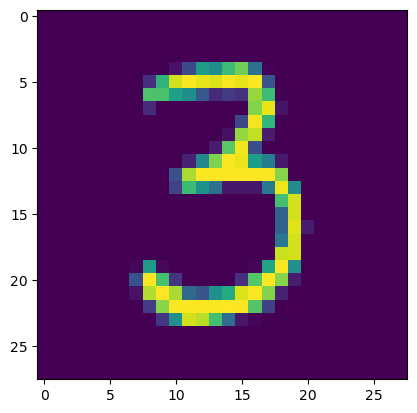

In [5]:
plt.imshow(X_train[50])

In [6]:
X_train = X_train/255
X_test = X_test/255

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [8]:
model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(50, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='sigmoid')
])

d:\HP\anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy']
              )

In [11]:
model.fit(X_train, Y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9122 - loss: 0.3019
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9585 - loss: 0.1392
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9681 - loss: 0.1043
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9738 - loss: 0.0843
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9774 - loss: 0.0732
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9801 - loss: 0.0625
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0552
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9844 - loss: 0.0484
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9861 - loss: 0.0422
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0373


In [12]:
## Trainingf data accuracy
# 0.9828

In [13]:
loss, accuracy = model.evaluate(X_test , Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9691 - loss: 0.1117


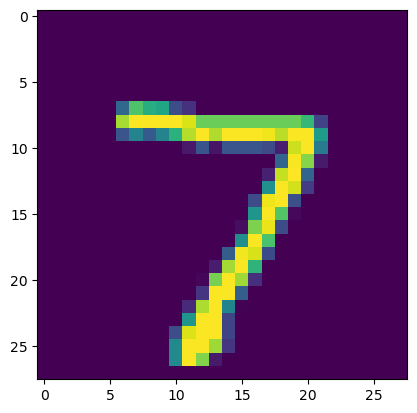

In [14]:
plt.imshow(X_test[0])

In [15]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [16]:
Y_pred[1]

array([1.1383242e-05, 1.7450166e-01, 9.9999988e-01, 1.4918718e-01,
       4.2781001e-10, 7.8679717e-05, 6.5870825e-07, 2.2040261e-03,
       1.3124586e-02, 1.1513832e-06], dtype=float32)

In [17]:
label_for_first_pred = np.argmax(Y_pred[0])

In [18]:
label_for_first_pred

np.int64(7)

In [19]:
Y_pred_labels = [np.argmax(i) for i in Y_pred]
Y_pred_labels

[np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(5),
 np.int64(9),
 np.int64(0),
 np.int64(6),
 np.int64(9),
 np.int64(0),
 np.int64(1),
 np.int64(5),
 np.int64(9),
 np.int64(7),
 np.int64(3),
 np.int64(4),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.int64(0),
 np.int64(7),
 np.int64(4),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(4),
 np.int64(7),
 np.int64(2),
 np.int64(7),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(7),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(4),
 np.int64(6),
 np.int64(3),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(9),
 np.int64(5),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(3),
 np.int64(7),
 np.int64(4),
 np.int64(6),
 np.int64(4),
 np.int64(3),
 np.int64(0),
 np.int64(7),
 np.in

In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
conf_mat = confusion_matrix(Y_test, Y_pred_labels)

In [22]:
conf_mat

array([[ 970,    0,    0,    2,    1,    2,    0,    1,    2,    2],
       [   2, 1113,    3,    3,    3,    0,    3,    2,    5,    1],
       [   5,    0,  975,   24,    6,    2,    1,   11,    8,    0],
       [   0,    0,    3,  991,    0,    1,    0,    5,    2,    8],
       [   2,    0,    1,    1,  959,    1,    1,    2,    0,   15],
       [   4,    1,    0,   13,    2,  861,    1,    0,    4,    6],
       [   8,    2,    1,    1,   13,    9,  918,    0,    4,    2],
       [   1,    1,    5,    6,    1,    0,    0,  996,    2,   16],
       [   5,    1,    4,   15,    7,    5,    1,    4,  925,    7],
       [   2,    2,    0,    6,    8,    2,    0,    4,    2,  983]])

Text(0.5, 47.7222222222222, 'Predicted Labels')

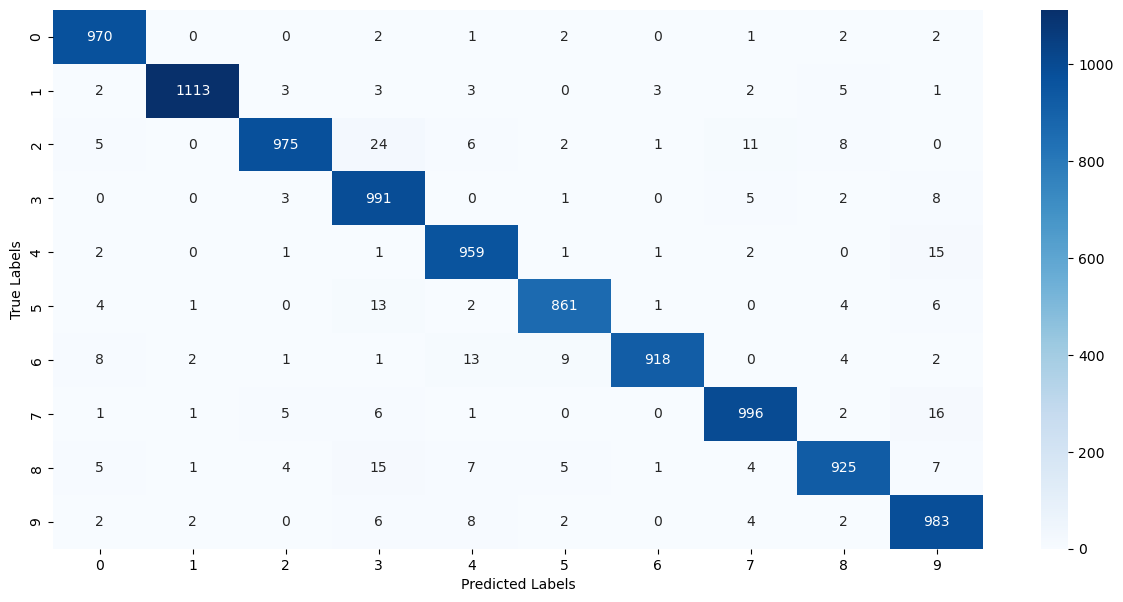

In [23]:
plt.figure(figsize=(15, 7 ))
sns.heatmap(conf_mat , annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

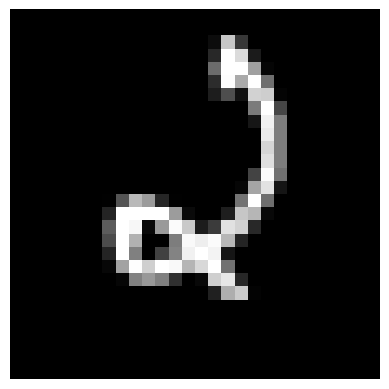

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
The model predicts the digit is: 2
Actual digit is: 2


In [25]:
import matplotlib.pyplot as plt
import numpy as np

index = np.random.randint(0, len(X_test))

input_image = X_test[index]

plt.imshow(input_image, cmap='gray')
plt.axis('off')
plt.show()

prediction = model.predict(input_image.reshape(1, 28, 28))

predicted_digit = np.argmax(prediction)

print("=" * 50)
print(f"The model predicts the digit is: {predicted_digit}")
print(f"Actual digit is: {Y_test[index]}")
print("=" * 50)